# SMMT 2025 - Predicting Strong-Growth UK Car Manufacturers
## Random Forest & XGBoost - Reworked modelling 


GitHub: https://github.com/SunkeAnandasai3784/SMMT-2025-UK-Car-Sales-Analysis

In [1]:
# 0. Imports
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, log_loss, confusion_matrix,
                             classification_report)
from xgboost import XGBClassifier
sns.set(style="whitegrid"); eps = 1e-6; RS = 42

In [2]:
# 1. Load VEH0160 data (works in Colab /content or locally)
CSV = "df_VEH0160_UK.csv"
path = CSV if os.path.exists(CSV) else f"/content/{CSV}"
df_veh0160_uk = pd.read_csv(path, encoding="latin1")
print("Raw shape:", df_veh0160_uk.shape)

Raw shape: (61226, 50)


In [3]:
# 2. Filter to Cars and reshape wide -> long (Make x Period)
cars = df_veh0160_uk[df_veh0160_uk["BodyType"] == "Cars"].copy()
quarter_cols = [c for c in cars.columns if "Q" in c and any(str(y) in c for y in range(2000, 2035))]
df_long = cars.melt(id_vars=["Make"], value_vars=quarter_cols,
                    var_name="Period", value_name="Registered").dropna(subset=["Registered"])
df_long["Registered"] = df_long["Registered"].astype(float)
df_long[["Year", "QuarterNo"]] = df_long["Period"].str.extract(r"(\d{4})\s*Q(\d)")
df_long["Year"] = df_long["Year"].astype(int); df_long["QuarterNo"] = df_long["QuarterNo"].astype(int)
df_long["Month"] = df_long["QuarterNo"].map({1:3,2:6,3:9,4:12})
df_long["Date"] = pd.to_datetime(dict(year=df_long["Year"], month=df_long["Month"], day=1)) + pd.offsets.MonthEnd(0)
print("Long shape:", df_long.shape)

Long shape: (1477440, 7)


In [4]:
# 3. Aggregate to Make x Date + lags
panel = (df_long.groupby(["Make","Date"], as_index=False)["Registered"].sum()
                .sort_values(["Make","Date"]))
g = ["Make"]
panel["Registered_lag1"] = panel.groupby(g)["Registered"].shift(1)
panel["Registered_lag4"] = panel.groupby(g)["Registered"].shift(4)
panel["MA3"] = panel.groupby(g)["Registered"].rolling(3).mean().reset_index(level=0, drop=True)
panel = panel.dropna(subset=["Registered_lag1","Registered_lag4","MA3"])

In [5]:
# 4. Engineered features
panel["YoY_Growth_Rate"] = (panel["Registered"]-panel["Registered_lag4"])/(panel["Registered_lag4"]+eps)
panel["QoQ_Growth_Rate"] = (panel["Registered"]-panel["Registered_lag1"])/(panel["Registered_lag1"]+eps)
panel["Volatility"] = panel.groupby(g)["Registered"].rolling(4).std().reset_index(level=0, drop=True)
total_market = panel.groupby("Date")["Registered"].transform("sum")
panel["Market_Share"] = panel["Registered"]/(total_market+eps)
panel = panel.dropna(subset=["YoY_Growth_Rate","QoQ_Growth_Rate","Volatility","Market_Share"])
print("Panel after features:", panel.shape)

Panel after features: (13756, 10)


In [6]:
# 5. Target (strong growth = YoY > 10%) and feature matrix (no leakage)
panel["Target"] = (panel["YoY_Growth_Rate"] > 0.10).astype(int)
feature_cols = ["QoQ_Growth_Rate","Volatility","Market_Share"]
X = panel[feature_cols].replace([np.inf,-np.inf], np.nan).fillna(0)
y = panel["Target"]
print("Class counts:", y.value_counts().to_dict(),
      "| positive share:", round(y.mean(),3),
      "| imbalance (neg/pos):", round((y==0).sum()/(y==1).sum(),2))

Class counts: {0: 11729, 1: 2027} | positive share: 0.147 | imbalance (neg/pos): 5.79


### Exploratory data analysis
Class balance and the correlation of the engineered inputs with the target.

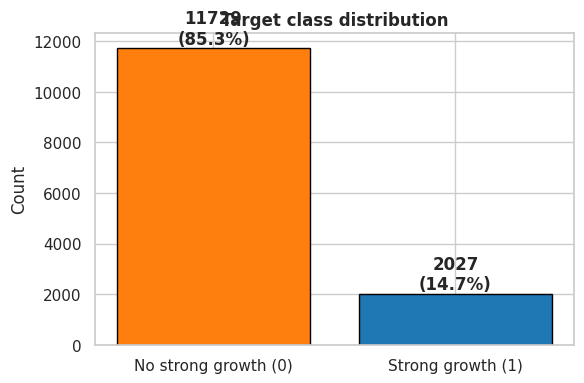

In [7]:
# Class distribution
plt.figure(figsize=(6,4))
vc = y.value_counts().sort_index()
bars = plt.bar(["No strong growth (0)","Strong growth (1)"], vc.values,
               color=["#ff7f0e","#1f77b4"], edgecolor="black")
for b in bars:
    h=b.get_height(); plt.text(b.get_x()+b.get_width()/2, h, f"{int(h)}\n({100*h/vc.sum():.1f}%)",
                               ha="center", va="bottom", fontweight="bold")
plt.ylabel("Count"); plt.title("Target class distribution", fontweight="bold")
plt.tight_layout(); plt.show()

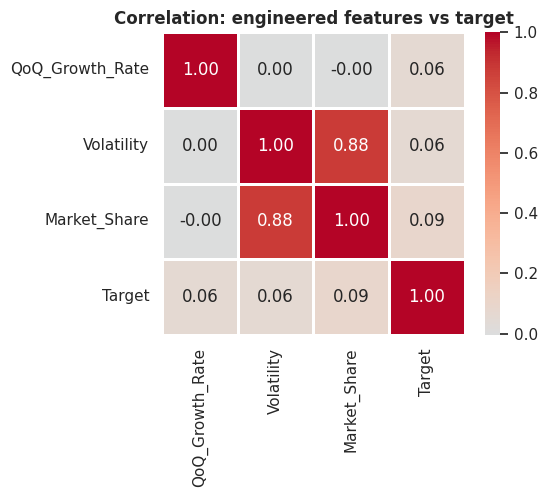

In [8]:
# Correlation of engineered features with the target
plt.figure(figsize=(6,5))
sns.heatmap(panel[feature_cols+["Target"]].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, square=True, linewidths=1)
plt.title("Correlation: engineered features vs target", fontweight="bold")
plt.tight_layout(); plt.show()

In [9]:
# 6. Stratified train / validation / test split + scale_pos_weight
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.25, random_state=RS, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=RS, stratify=y_temp)
spw = (y_train==0).sum()/(y_train==1).sum()
print(f"Train {len(y_train)}  Val {len(y_val)}  Test {len(y_test)}  scale_pos_weight={spw:.2f}")

results = {}
def evaluate(name, proba_val, proba_test):
    pv=(proba_val>=.5).astype(int); pt=(proba_test>=.5).astype(int)
    results[name]=dict(
        val_auc=roc_auc_score(y_val,proba_val), val_logloss=log_loss(y_val,proba_val),
        test_acc=accuracy_score(y_test,pt), test_precision=precision_score(y_test,pt,zero_division=0),
        test_recall=recall_score(y_test,pt,zero_division=0), test_f1=f1_score(y_test,pt,zero_division=0),
        test_auc=roc_auc_score(y_test,proba_test), test_logloss=log_loss(y_test,proba_test),
        cm=confusion_matrix(y_test,pt))
    r=results[name]
    print(f"{name}\n  test AUC {r['test_auc']:.3f} | F1 {r['test_f1']:.3f} | recall {r['test_recall']:.3f} | "
          f"precision {r['test_precision']:.3f} | logloss {r['test_logloss']:.3f} | CM {r['cm'].tolist()}")
def plot_cm(name, title):
    cm=results[name]['cm']
    plt.figure(figsize=(5,4))
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
                xticklabels=['No growth','Strong growth'], yticklabels=['No growth','Strong growth'])
    plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title(title, fontweight='bold')
    plt.tight_layout(); plt.show()

Train 7737  Val 2580  Test 3439  scale_pos_weight=5.79


## 1. Random Forest

### 1.1 Baseline and overfitting assessment
The baseline is a deep, unconstrained forest with **no** class weighting. We
compare train vs validation log loss to expose overfitting, then plot learning
curves against tree depth (regularisation) and training-set size.

In [10]:
# RF baseline: deep, unconstrained, no class weighting
rf_base = RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_leaf=1,
                                 random_state=RS, n_jobs=-1).fit(X_train, y_train)
evaluate("RF baseline", rf_base.predict_proba(X_val)[:,1], rf_base.predict_proba(X_test)[:,1])
tr = log_loss(y_train, rf_base.predict_proba(X_train)[:,1])
print(f"  >> TRAIN logloss {tr:.3f} vs VAL {results['RF baseline']['val_logloss']:.3f} "
      f"(large gap = overfitting)")

RF baseline
  test AUC 0.939 | F1 0.581 | recall 0.546 | precision 0.620 | logloss 0.270 | CM [[2762, 170], [230, 277]]
  >> TRAIN logloss 0.062 vs VAL 0.266 (large gap = overfitting)


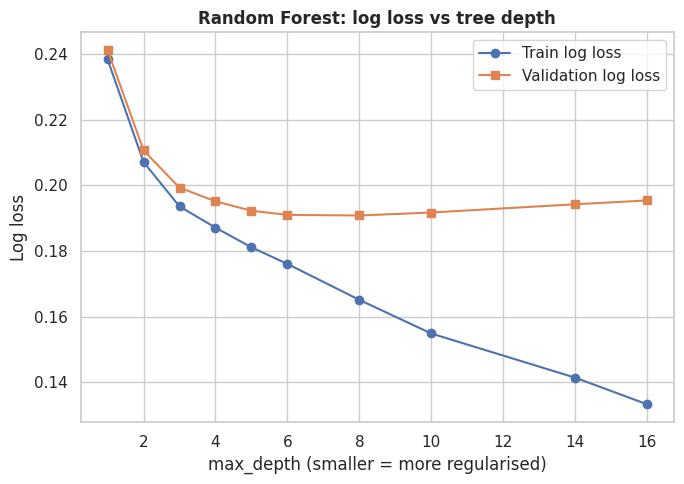

In [11]:
# RF learning curve vs tree depth (train vs validation log loss)
depths=[1,2,3,4,5,6,8,10,14,None]; tr_ll=[]; va_ll=[]
for d in depths:
    m=RandomForestClassifier(n_estimators=200, max_depth=d, min_samples_leaf=5,
                             random_state=RS, n_jobs=-1).fit(X_train,y_train)
    tr_ll.append(log_loss(y_train,m.predict_proba(X_train)[:,1]))
    va_ll.append(log_loss(y_val,m.predict_proba(X_val)[:,1]))
xd=[d if d else 16 for d in depths]
plt.figure(figsize=(7,5))
plt.plot(xd,tr_ll,'o-',label='Train log loss'); plt.plot(xd,va_ll,'s-',label='Validation log loss')
plt.xlabel('max_depth (smaller = more regularised)'); plt.ylabel('Log loss')
plt.title('Random Forest: log loss vs tree depth', fontweight='bold'); plt.legend()
plt.tight_layout(); plt.show()

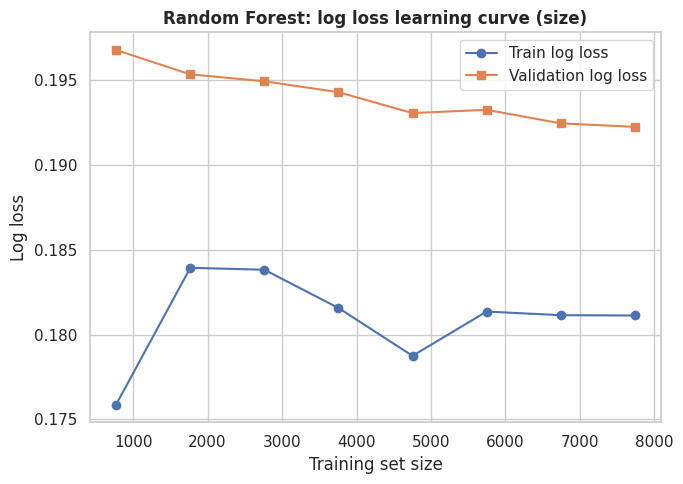

In [12]:
# RF learning curve vs training-set size
sizes=np.linspace(0.1,1.0,8); ts=[]; vs=[]
for fr in sizes:
    n=int(len(X_train)*fr)
    m=RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=5,
                             random_state=RS, n_jobs=-1).fit(X_train.iloc[:n],y_train.iloc[:n])
    ts.append(log_loss(y_train.iloc[:n],m.predict_proba(X_train.iloc[:n])[:,1]))
    vs.append(log_loss(y_val,m.predict_proba(X_val)[:,1]))
plt.figure(figsize=(7,5))
plt.plot((sizes*len(X_train)).astype(int),ts,'o-',label='Train log loss')
plt.plot((sizes*len(X_train)).astype(int),vs,'s-',label='Validation log loss')
plt.xlabel('Training set size'); plt.ylabel('Log loss')
plt.title('Random Forest: log loss learning curve (size)', fontweight='bold'); plt.legend()
plt.tight_layout(); plt.show()

**Overfitting assessment (RF).** The baseline forest drives *training* log
loss down to ~0.06 while *validation* log loss stays ~0.27 - a large gap that
signals memorisation rather than generalisation. The depth curve confirms this:
training log loss falls monotonically with depth, but validation log loss bottoms
out around depth 6-8 and then rises. This motivates regularising the tree depth
(and leaf size) during tuning. The size curve shows the two losses converging as
data grows, i.e. more data would help but the main lever here is regularisation.

### 1.2 Hyperparameter tuning (before vs after)
Grid search over depth, leaf size and number of trees (the RF regularisers),
optimising cross-validated ROC-AUC.

In [13]:
grid_rf = GridSearchCV(RandomForestClassifier(random_state=RS, n_jobs=-1),
    {"n_estimators":[100,200],"max_depth":[3,4,5],"min_samples_leaf":[3,5,10],"max_features":["sqrt"]},
    scoring="roc_auc", cv=5, n_jobs=-1).fit(X_train, y_train)
print("Best params:", grid_rf.best_params_)
rf_tuned = grid_rf.best_estimator_
evaluate("RF tuned", rf_tuned.predict_proba(X_val)[:,1], rf_tuned.predict_proba(X_test)[:,1])

Best params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 100}
RF tuned
  test AUC 0.949 | F1 0.626 | recall 0.582 | precision 0.678 | logloss 0.190 | CM [[2792, 140], [212, 295]]


### 1.3 Class-imbalance handling (before vs after)
The same tuned forest, now with `class_weight="balanced"`.

RF tuned + balanced
  test AUC 0.948 | F1 0.648 | recall 0.974 | precision 0.486 | logloss 0.269 | CM [[2409, 523], [13, 494]]


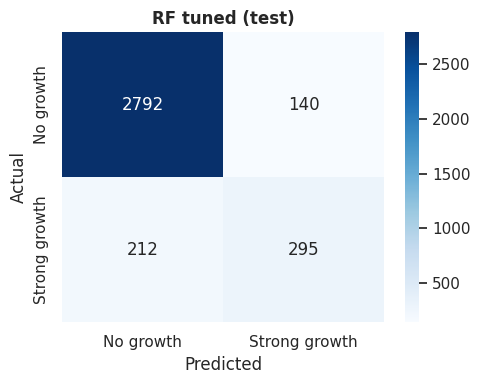

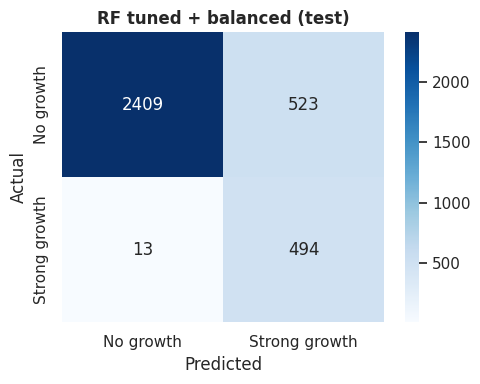

In [14]:
rf_bal = RandomForestClassifier(class_weight="balanced", random_state=RS, n_jobs=-1,
                                **grid_rf.best_params_).fit(X_train, y_train)
evaluate("RF tuned + balanced", rf_bal.predict_proba(X_val)[:,1], rf_bal.predict_proba(X_test)[:,1])
plot_cm("RF tuned", "RF tuned (test)")
plot_cm("RF tuned + balanced", "RF tuned + balanced (test)")

**Discussion (RF imbalance).** Balancing the classes flips recall from ~0.58
to ~0.97 - it now catches almost every strong-growth manufacturer - but precision
collapses from ~0.68 to ~0.49 because false positives explode (roughly 140 -> 520
on the test set). In other words, `class_weight="balanced"` buys recall at the cost
of a flood of false alarms, which is exactly the trade-off that must be weighed
against the business use-case (is a missed grower or a false alarm more costly?).

## 2. XGBoost

### 2.1 Baseline and overfitting assessment
A high-learning-rate, unregularised XGBoost. Because boosting is iterative, the
natural learning curve is **log loss vs boosting round (epoch)** via `eval_set`.

XGB baseline
  test AUC 0.935 | F1 0.593 | recall 0.584 | precision 0.602 | logloss 0.323 | CM [[2736, 196], [211, 296]]


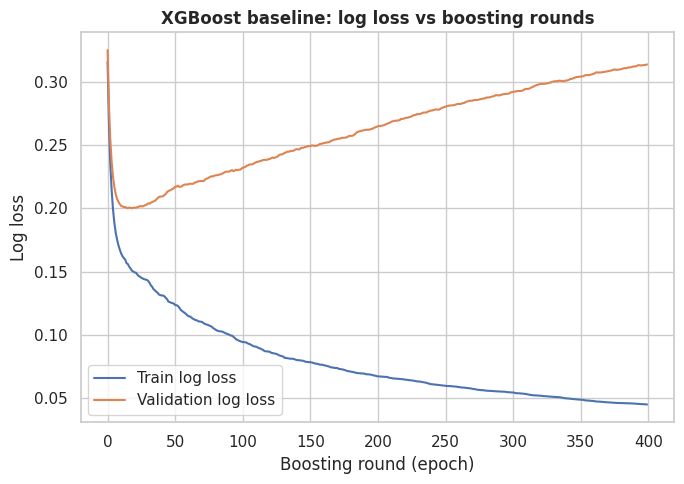

In [15]:
xgb_base = XGBClassifier(n_estimators=400, learning_rate=0.3, max_depth=6,
                         reg_lambda=0, reg_alpha=0, subsample=1.0, colsample_bytree=1.0,
                         eval_metric="logloss", random_state=RS)
xgb_base.fit(X_train, y_train, eval_set=[(X_train,y_train),(X_val,y_val)], verbose=False)
evaluate("XGB baseline", xgb_base.predict_proba(X_val)[:,1], xgb_base.predict_proba(X_test)[:,1])
ev = xgb_base.evals_result()
plt.figure(figsize=(7,5))
plt.plot(ev['validation_0']['logloss'], label='Train log loss')
plt.plot(ev['validation_1']['logloss'], label='Validation log loss')
plt.xlabel('Boosting round (epoch)'); plt.ylabel('Log loss')
plt.title('XGBoost baseline: log loss vs boosting rounds', fontweight='bold'); plt.legend()
plt.tight_layout(); plt.show()

**Overfitting assessment (XGB).** The baseline curve is a classic overfitting
signature: validation log loss reaches its minimum (~0.20) after only ~15-20 rounds
and then climbs steadily, while training log loss keeps falling toward ~0.05. The
model is fitting noise after the early rounds. The fixes are a lower learning rate,
L1/L2 regularisation, sub-sampling and early stopping - explored next.

### 2.2 Tuning the learning rate and regularisation (with new learning curves)

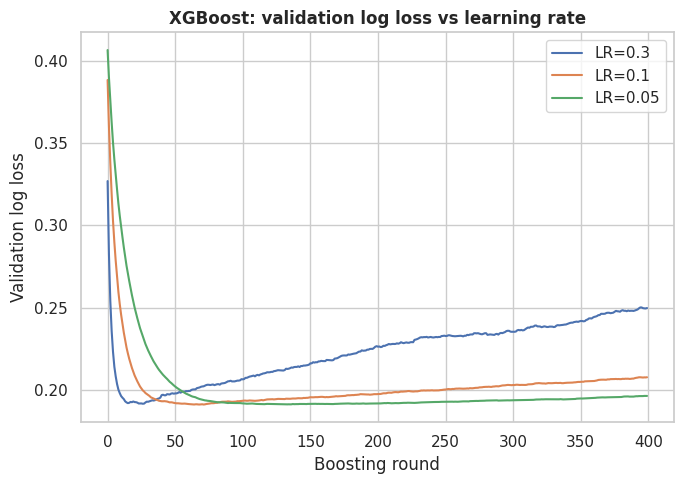

In [16]:
# Effect of LEARNING RATE on validation log loss
plt.figure(figsize=(7,5))
for lr in [0.3,0.1,0.05]:
    m=XGBClassifier(n_estimators=400, learning_rate=lr, max_depth=4, reg_lambda=1.0,
                    subsample=0.8, colsample_bytree=0.8, eval_metric="logloss", random_state=RS)
    m.fit(X_train,y_train,eval_set=[(X_val,y_val)],verbose=False)
    plt.plot(m.evals_result()['validation_0']['logloss'], label=f'LR={lr}')
plt.xlabel('Boosting round'); plt.ylabel('Validation log loss')
plt.title('XGBoost: validation log loss vs learning rate', fontweight='bold'); plt.legend()
plt.tight_layout(); plt.show()

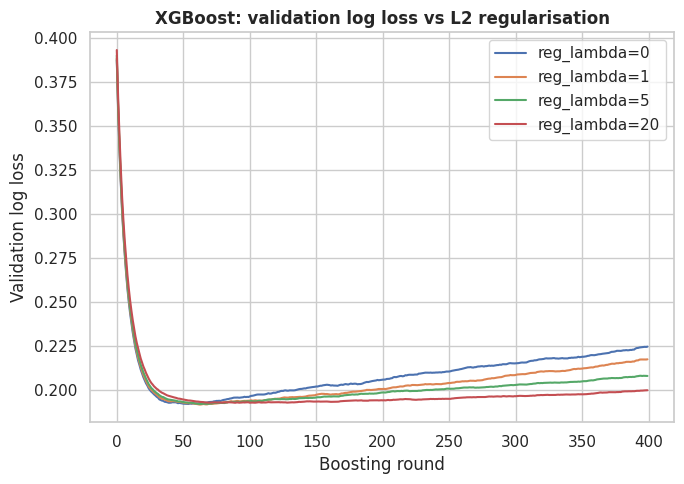

In [17]:
# Effect of L2 REGULARISATION (reg_lambda) on validation log loss
plt.figure(figsize=(7,5))
for rl in [0,1,5,20]:
    m=XGBClassifier(n_estimators=400, learning_rate=0.1, max_depth=5, reg_lambda=rl,
                    subsample=0.8, colsample_bytree=0.8, eval_metric="logloss", random_state=RS)
    m.fit(X_train,y_train,eval_set=[(X_val,y_val)],verbose=False)
    plt.plot(m.evals_result()['validation_0']['logloss'], label=f'reg_lambda={rl}')
plt.xlabel('Boosting round'); plt.ylabel('Validation log loss')
plt.title('XGBoost: validation log loss vs L2 regularisation', fontweight='bold'); plt.legend()
plt.tight_layout(); plt.show()

Best iteration (early stopping): 133
XGB tuned
  test AUC 0.948 | F1 0.631 | recall 0.590 | precision 0.680 | logloss 0.191 | CM [[2791, 141], [208, 299]]


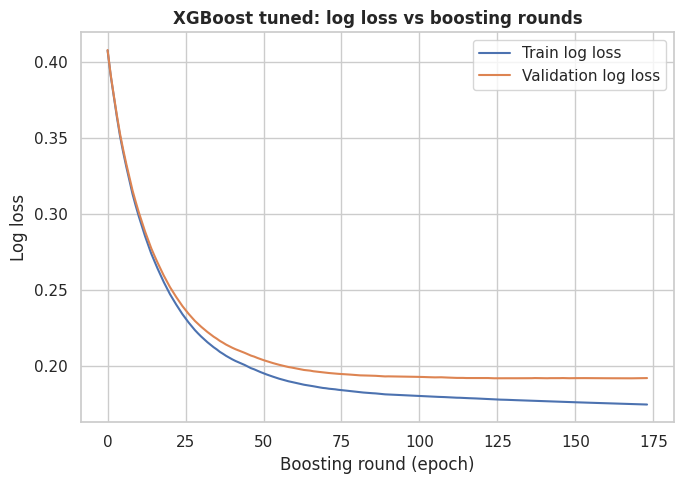

In [18]:
# Tuned XGBoost: low LR + regularisation + sub-sampling + early stopping
xgb_tuned = XGBClassifier(n_estimators=600, learning_rate=0.05, max_depth=4, reg_lambda=5.0,
                          reg_alpha=0.5, subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
                          eval_metric="logloss", early_stopping_rounds=40, random_state=RS)
xgb_tuned.fit(X_train, y_train, eval_set=[(X_train,y_train),(X_val,y_val)], verbose=False)
print("Best iteration (early stopping):", xgb_tuned.best_iteration)
evaluate("XGB tuned", xgb_tuned.predict_proba(X_val)[:,1], xgb_tuned.predict_proba(X_test)[:,1])
ev=xgb_tuned.evals_result()
plt.figure(figsize=(7,5))
plt.plot(ev['validation_0']['logloss'], label='Train log loss')
plt.plot(ev['validation_1']['logloss'], label='Validation log loss')
plt.xlabel('Boosting round (epoch)'); plt.ylabel('Log loss')
plt.title('XGBoost tuned: log loss vs boosting rounds', fontweight='bold'); plt.legend()
plt.tight_layout(); plt.show()

**Discussion (XGB tuning).** Lowering the learning rate slows convergence but
reaches a lower, flatter validation minimum; raising `reg_lambda` lifts the curve
slightly early on but suppresses the late-round over-fitting climb. The tuned model
(LR=0.05, `reg_lambda`=5, `reg_alpha`=0.5, sub-sampling, `min_child_weight`=5, early
stopping at ~130 rounds) keeps train and validation log loss tracking together and
cuts test log loss from ~0.32 to ~0.19 - a clear before/after improvement.

### 2.3 Class-imbalance handling (before vs after)
The tuned model with `scale_pos_weight` set to the negative/positive ratio.

XGB tuned + scale_pos_weight
  test AUC 0.948 | F1 0.660 | recall 0.917 | precision 0.515 | logloss 0.261 | CM [[2494, 438], [42, 465]]


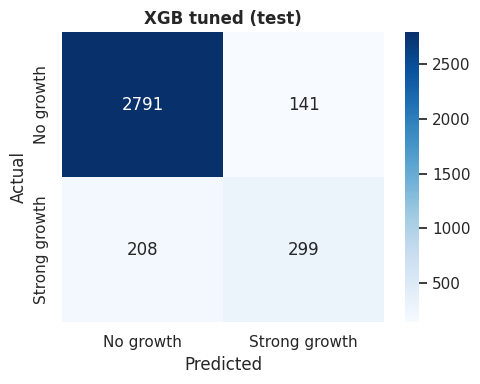

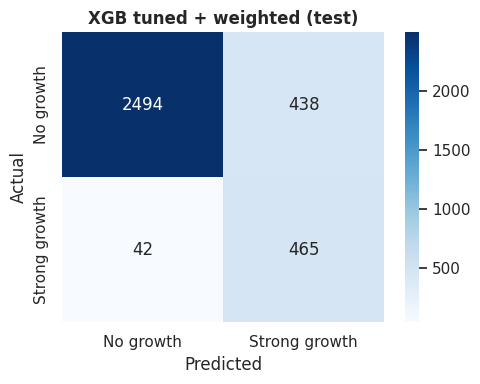

In [19]:
xgb_w = XGBClassifier(n_estimators=600, learning_rate=0.05, max_depth=4, reg_lambda=5.0,
                      reg_alpha=0.5, subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
                      scale_pos_weight=spw, eval_metric="logloss", early_stopping_rounds=40, random_state=RS)
xgb_w.fit(X_train, y_train, eval_set=[(X_train,y_train),(X_val,y_val)], verbose=False)
evaluate("XGB tuned + scale_pos_weight", xgb_w.predict_proba(X_val)[:,1], xgb_w.predict_proba(X_test)[:,1])
plot_cm("XGB tuned", "XGB tuned (test)")
plot_cm("XGB tuned + scale_pos_weight", "XGB tuned + weighted (test)")

**Discussion (XGB imbalance).** As with RF, `scale_pos_weight` raises recall
sharply (~0.59 -> ~0.92) but lowers precision (~0.68 -> ~0.52). XGBoost handles the
trade-off slightly better than RF (higher F1 with fewer false positives), because
its regularisation limits how aggressively it chases the minority class. Whether to
apply weighting depends on the relative cost of missed growers vs false alarms.

## 3. Feature importance
Which engineered inputs drive each tuned model.

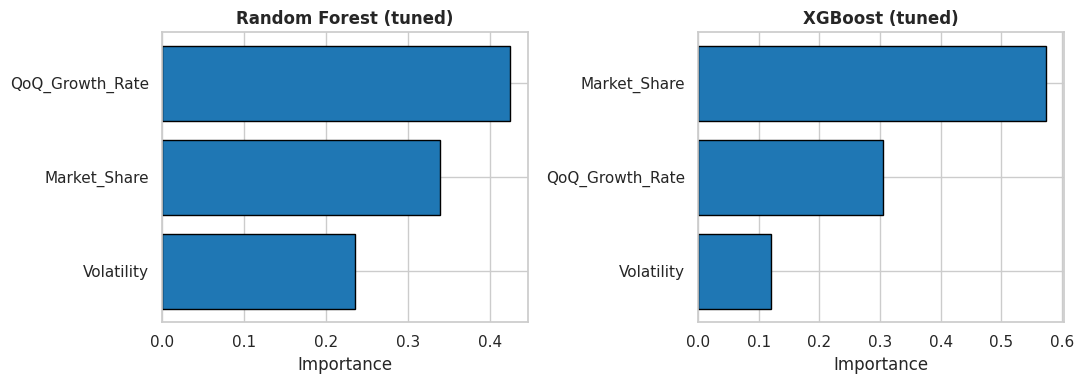

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(11,4))
for a,(name,mdl) in zip(ax, [("Random Forest (tuned)",rf_tuned),("XGBoost (tuned)",xgb_tuned)]):
    imp = pd.Series(mdl.feature_importances_, index=feature_cols).sort_values()
    a.barh(imp.index, imp.values, color="#1f77b4", edgecolor="black")
    a.set_title(name, fontweight="bold"); a.set_xlabel("Importance")
plt.tight_layout(); plt.show()

## 4. Master comparison and ROC

In [21]:
order=["RF baseline","RF tuned","RF tuned + balanced",
       "XGB baseline","XGB tuned","XGB tuned + scale_pos_weight"]
cols=["test_acc","test_precision","test_recall","test_f1","test_auc","test_logloss"]
summary=pd.DataFrame([{**{"model":k},**{c:results[k][c] for c in cols}} for k in order])
print(summary.round(3).to_string(index=False))

                       model  test_acc  test_precision  test_recall  test_f1  test_auc  test_logloss
                 RF baseline     0.884           0.620        0.546    0.581     0.939         0.270
                    RF tuned     0.898           0.678        0.582    0.626     0.949         0.190
         RF tuned + balanced     0.844           0.486        0.974    0.648     0.948         0.269
                XGB baseline     0.882           0.602        0.584    0.593     0.935         0.323
                   XGB tuned     0.899           0.680        0.590    0.631     0.948         0.191
XGB tuned + scale_pos_weight     0.860           0.515        0.917    0.660     0.948         0.261


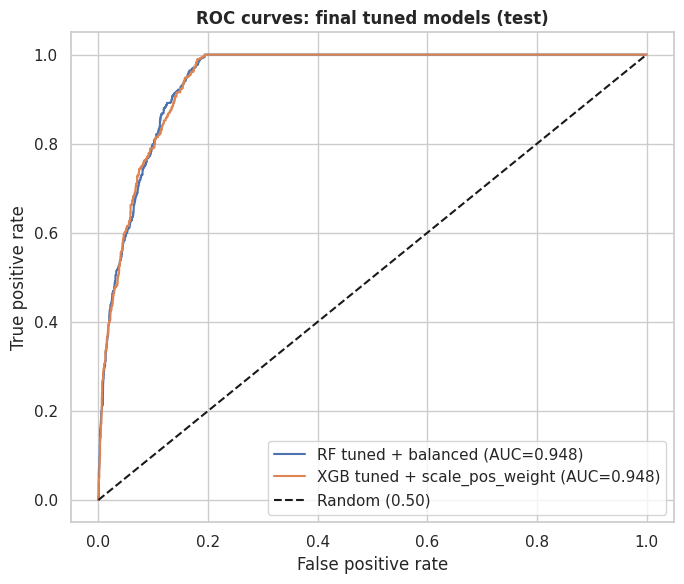

In [22]:
plt.figure(figsize=(7,6))
for name,mdl in [("RF tuned + balanced",rf_bal),("XGB tuned + scale_pos_weight",xgb_w)]:
    pr=mdl.predict_proba(X_test)[:,1]; fpr,tpr,_=roc_curve(y_test,pr)
    plt.plot(fpr,tpr,label=f"{name} (AUC={roc_auc_score(y_test,pr):.3f})")
plt.plot([0,1],[0,1],'k--',label='Random (0.50)')
plt.xlabel('False positive rate'); plt.ylabel('True positive rate')
plt.title('ROC curves: final tuned models (test)', fontweight='bold'); plt.legend()
plt.tight_layout(); plt.show()